In [20]:
#importing required modules and dependencies
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

# Data Analysis

In [3]:
#load dataset and see few rows
df = pd.read_csv('/kaggle/input/suicide-watch/Suicide_Detection.csv')
df.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [4]:
#remove irrelevant column
df = df.drop('Unnamed: 0', axis=1)

#check for missing values
df.isnull().sum()

text     0
class    0
dtype: int64

class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


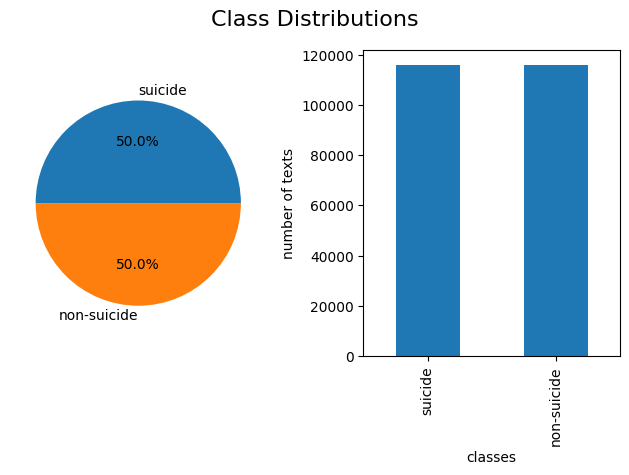

In [5]:
#check class distributions
class_counts = df['class'].value_counts()
print(class_counts)

#plots to visualise class distributions
fig, axs = plt.subplots(1, 2)

class_counts.plot(kind='pie', autopct='%1.1f%%', ax=axs[0])
axs[0].set_ylabel('')

class_counts.plot(kind='bar', ax=axs[1])
axs[1].set_xlabel('classes')
axs[1].set_ylabel('number of texts')

fig.suptitle('Class Distributions', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
#check number of words in each text
df['len'] = df['text'].apply(lambda x: len(x.split(' ')))
df['len'].describe()

count    232074.000000
mean        131.546438
std         222.081581
min           1.000000
25%          26.000000
50%          60.000000
75%         154.000000
max       15632.000000
Name: len, dtype: float64

In [7]:
#a quantile is a statistical value that divides the dataset into intervals
#a quantile at 0.9 returns the value below which 90% of the data falls
for i in [0.8, 0.9, 0.95, 0.99, 0.995, 0.999]:
    print(i*100, '% :', df['len'].quantile(i))

80.0 % : 190.0
90.0 % : 317.0
95.0 % : 470.0
99.0 % : 960.0
99.5 % : 1264.6350000000093
99.9 % : 2198.8540000000503


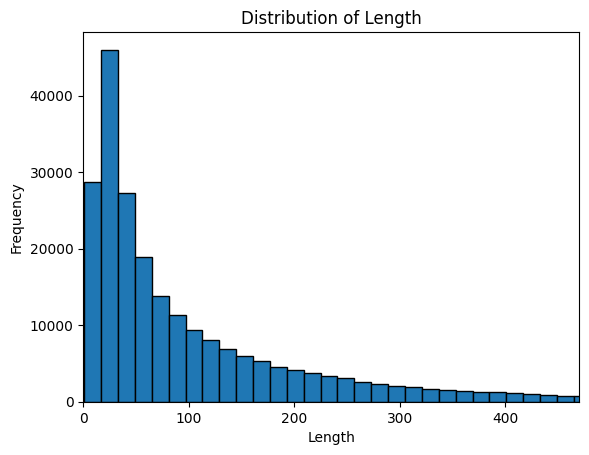

In [8]:
#visualize length distribution of texts
plt.hist(df['len'], bins=977, edgecolor='black')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Length')
plt.xlim(0, 470) #setting range on x-axis for plot to make sense, it visualises 95% of the dataset
plt.show()